In [ ]:
#We generated four groups of data. NAI_rep,NAI_rep2,DMSO_rep1，DMSO_rep2
ref=/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S.fasta
outdir=/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult

NAI_1_fast5=/data1/huangyong/Project/Nano_seq/Nano_seq/Fast5/1010_16SDeg_NAI_rep1
NAI_2_fast5=/data1/huangyong/Project/Nano_seq/Nano_seq/Fast5/1010_16SDeg_NAI_rep2
DMSO_1_fast5=/data1/huangyong/Project/Nano_seq/Nano_seq/Fast5/1010_16SDeg_DMSO
DMSO_2_fast5=/data1/huangyong/Project/Nano_seq/Nano_seq/Fast5/1020_16SDeg_DMSO2

NAI_1_fq=/data1/huangyong/Project/Nano_seq/Nano_seq/Fastq/2022101016SDeg_NAI1.fastq
NAI_2_fq=/data1/huangyong/Project/Nano_seq/Nano_seq/Fastq/2022101016SDeg_NAI2.fastq
DMSO_1_fq=/data1/huangyong/Project/Nano_seq/Nano_seq/Fastq/2022101016SDeg_DMSO.fastq 
DMSO_2_fq=/data1/huangyong/Project/Nano_seq/Nano_seq/Fastq/2022102016SDeg_DMSO2.fastq

srun  python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q ${NAI_1_fq} -s ${NAI_1_fast5} -d ${outdir} -n NAI_rep1 -i
srun  python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q ${NAI_2_fq} -s ${NAI_2_fast5} -d ${outdir} -n NAI_rep2 -i
srun  python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q ${DMSO_1_fq} -s ${DMSO_1_fast5} -d ${outdir} -n DMSO_rep1 -i
srun  python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q ${DMSO_2_fq} -s ${DMSO_2_fast5} -d ${outdir} -n DMSO_rep2 -i

#analyse the event files from replicates separately and then combine together 
#1、批量按照10nt resolution进行event文件的分割
srun  --nodelist node502 python /data1/huangyong/Project/Nano_seq/nanoDISH/pickIntermediate.py -i NAI1.collapse.event  -g BS16S  -d splitNAI_rep1 -s 30 -e 1540 -b 10 -m &
srun  --nodelist node505 python /data1/huangyong/Project/Nano_seq/nanoDISH/pickIntermediate.py -i NAI2.collapse.event  -g BS16S  -d splitNAI_rep2 -s 30 -e 1540 -b 10 -m &
srun  --nodelist node503 python /data1/huangyong/Project/Nano_seq/nanoDISH/pickIntermediate.py -i DMSO1.collapse.event  -g BS16S  -d splitDMSO_rep1 -s 30 -e 1540 -b 10 -m &
srun  --nodelist node504 python /data1/huangyong/Project/Nano_seq/nanoDISH/pickIntermediate.py -i DMSO2.collapse.event  -g BS16S  -d splitDMSO_rep2 -s 30 -e 1540 -b 10 -m &
srun  --nodelist node525 python /data1/huangyong/Project/Nano_seq/nanoDISH/pickIntermediate.py -i DMSO.collapse.event  -g BS16S  -d splitDMSO -s 30 -e 1540 -b 10 -m &
srun  --nodelist node501 python /data1/huangyong/Project/Nano_seq/nanoDISH/pickIntermediate.py -i NAI.collapse.event  -g BS16S  -d splitNAI -s 30 -e 1540 -b 10 -m &

#2、分别对每个intermediate计算Modified base,并转成vectors
for i in {200..1540..10}; do python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m splitNAI_rep1/BS16S_$i.event -u splitDMSO_rep1/BS16S_$i.event -l $i -b 10 -GA 0.01 -NU 0.01 & done
for i in {200..1540..10}; do python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m splitNAI_rep2/BS16S_$i.event -u splitDMSO_rep2/BS16S_$i.event -l $i -b 10 -GA 0.01 -NU 0.01 & done
for i in {200..1540..10}; do python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m splitNAI/BS16S_$i.event -u splitDMSO/BS16S_$i.event -l $i -b 10 -GA 0.005 -NU 0.005 & done

#3、分别对每个intermediate计算平均reactivity scores
for i in {200..1540..10}; do srun python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m splitNAI_rep1/BS16S_$i.event.profile.vect -u splitDMSO_rep1/BS16S_$i.event.profile.vect -o result/meanScores_rep1/new$i -l $i -b 10 -s mean ; done
for i in {200..1540..10}; do srun python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m splitNAI_rep2/BS16S_$i.event.profile.vect -u splitDMSO_rep2/BS16S_$i.event.profile.vect -o result/meanScores_rep2/new$i -l $i -b 10 -s mean ; done
for i in {200..1540..10}; do srun python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m splitNAI/BS16S_$i.event.profile.vect  -u splitDMSO/BS16S_$i.event.profile.vect  -o result/meanScores/new$i -l $i -b 10 -s mean & done

#4、对coverage高的几个点（270，320，670，1530,1540）分析异质性结构



In [3]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None
from collections import Counter
import scipy.stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from statistics import mean
from scipy import stats
from sklearn.decomposition import PCA
import umap
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, HDBSCAN
import math
from sklearn.metrics import silhouette_score
#import hypertools as hyp
from RNA import General,Structure, Visual
import matplotlib
%matplotlib inline

2026-03-26 22:42:04.584732: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
def CalculateSHAPEFromBitvector_control(Modvect,Unmodvect,alpha=1):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def Normal_SHAPE(inlist,windowsize=200,step=5): #采用icSHAPE-pipe的策略，在Windows内，top5%为1，最低5%为0
    shape=[[] for i in range(len(inlist))]
    finalshape=[0 for i in range(len(inlist))]
    start=0
    while start+windowsize< len(inlist):
        sublist=np.array(inlist[start:start+windowsize])
        s95=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 95)
        s5=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 5)
        subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in sublist]
        for i in range(windowsize):
            shape[start+i].append(subshape[i])
        start+=step
    #处理最后一个window
    endsublist=np.array(inlist[start:])
    s95=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 95)
    s5=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 5)
    subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in endsublist]
    for i in range(len(endsublist)):
        shape[start+i].append(subshape[i])
    #对每个位置的值求平均
    for i in range(len(inlist)):
        finalshape[i]=mean(shape[i])
    return finalshape
    
def get_index(lst=None, item=''):
    return [index for (index,value) in enumerate(lst) if value == item]


def color_SHAPE(shape_list, cutoff=[0.3, 0.5, 0.7]):
    """
    shape_list              -- A list of SHAPE scores
    cutoff                  -- Cutoff of SHAPE color boundaries.
    
    Transform SHAPE values to color blocks
    """
    color_blocks=[]
    for value in shape_list:
        if value == 'NULL':
            color_blocks.append('lightgray')
        else:
            shape = float(value)
            if shape < cutoff[0]:
                color_blocks.append('black')
            elif shape < cutoff[1]:
                color_blocks.append('blue')
            elif shape < cutoff[2]:
                color_blocks.append('orange')
            else:
                color_blocks.append('red')
    
    return color_blocks

def SHAPEWindowcorrelation(shape1,shape2,windowsize):
    my_list1 = [0 if math.isnan(x) else x for x in shape1]
    my_list2 = [0 if math.isnan(x) else x for x in shape2]
    corre=[]
    start=0
    size=windowsize
    while start+size < len(my_list1):
        end=start+size
        subshape1=my_list1[start:end]
        subshape2=my_list2[start:end]
        t, p = scipy.stats.pearsonr(subshape1, subshape2)
        corre.append(round(t, 3))
        start+=1
    head=[0 for i in range(int(windowsize/2))]
    return head+corre+head

def plotPCA(pcadata,clust_ids,samplelabel,cluser_ratio):
    """
    pcadata                       --The PCA dataframe in which include two columns(PC1 and PC2)
    clust_ids                     --A list of cluster labels of each reads. e.g [0,0,1,2,0,1,2]
    cluser_ratio                  -- The reads ratio of each cluster.
    outfile                       -- The output figure.
    Plot the PCA clustering result 
    """    
    cluster_color = { 0: 'red', 1: '#FF7F00', 2: '#FF00FF',3:'#0000FF',4:'yellow',5:'black'}
    fig = plt.figure(figsize = (6,6))
    ax = fig.add_subplot(111)
    plt.scatter(pcadata['PC1'], pcadata['PC2'], c = [cluster_color[x]  if x in samplelabel else 'gray' for x in clust_ids], s = 20, alpha = 0.50 )
    ax.set_xlabel('PC 1', fontsize = 15)
    ax.set_ylabel('PC 2', fontsize = 15)
    N=len(cluser_ratio)
    for i in range(N):
        ax.text(0.05,0.95-0.05*i,'Cluter{}: {:.2%}'.format(i,cluser_ratio[i]),c=cluster_color[i], fontsize = 12, transform=ax.transAxes)
    ax.set_aspect('equal', 'box')
    plt.axis('equal')
    plt.show()
    #plt.savefig(outfile)
    #plt.close()
def filtVector(vector,posilist,minmod):
    start=posilist[0]
    end=posilist[1]
    temp_vet=vector.iloc[:,start:end].fillna(0)
    temp_totalnum=temp_vet.apply(lambda x: x.sum(),axis=1)
    filtvector=vector[temp_totalnum>minmod]
    return filtvector
def rainbowPlot(probList, ax, length=None, lw=0.8):
    max_height = 0
    for left,right in probList:
        x = (left+right)/2
        width = (right-left)
        height = width*0.01
        max_height = max(max_height, height/2)
        circle = matplotlib.patches.Arc((x, 0), width=width, angle=0, height=height, theta1=0, theta2=180, lw=lw)
        tmp = ax.add_artist(circle)
    ax.set_ylim(0, max_height)
def fill_ends(row):
    first_valid_index = int(row.first_valid_index())
    last_valid_index = int(row.last_valid_index())
    row.iloc[:first_valid_index] = 0
    row.iloc[last_valid_index + 1:] = 0
    return row

Open event file finished...
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
15

/tmp/ipykernel_18794/4029025581.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(NAI1lengthlist,shade=True,color='red',label='NAI-N3_rep1')
/tmp/ipykernel_18794/4029025581.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(NAI2lengthlist,shade=True,color='purple',label='NAI-N3_rep2')
/tmp/ipykernel_18794/4029025581.py:33: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(DMSO1lengthlist,shade=True,color='green',label='DMSO_rep1')
/tmp/ipykernel_18794/4029025581.py:34: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code

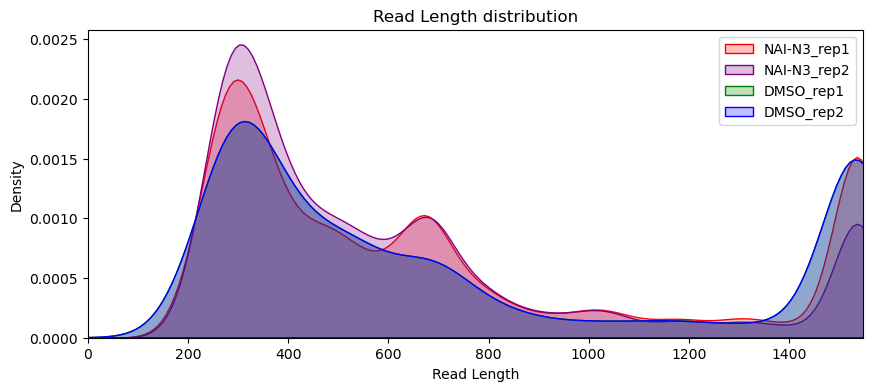

In [7]:
#两个Replicate间的分析
#plot the reads distributions 
def calculateLengthDistribution(Eventfile,start=50,end=1548,trim=True):
    lengthlist=[]
    df=pd.read_csv(Eventfile,sep='\t',index_col=0)
    print('Open event file finished...')
    b=0
    for i in df.groupby('read_name'): #遍历每个read，按照长度分类
        b+=1
        if not (b%1000):
            print(b)            #显示进度
        pos=i[1]['position'].tolist()
        EndPos=pos[-1]
        StartPos=pos[0]
        if trim:
            if StartPos<start and EndPos>=start and EndPos<=end:
                lengthlist.append(EndPos)
        else:
            lengthlist.append(EndPos-StartPos)
    return lengthlist
NAI1='/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/NAI1.collapse.event'
NAI1lengthlist=calculateLengthDistribution(NAI1)
NAI2='/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/NAI2.collapse.event'
NAI2lengthlist=calculateLengthDistribution(NAI2)
DMSO1='/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/DMSO1.collapse.event'
DMSO1lengthlist=calculateLengthDistribution(DMSO1)
DMSO2='/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/DMSO1.collapse.event'
DMSO2lengthlist=calculateLengthDistribution(DMSO2)

plt.figure(figsize=(10,4))
sns.kdeplot(NAI1lengthlist,shade=True,color='red',label='NAI-N3_rep1')
sns.kdeplot(NAI2lengthlist,shade=True,color='purple',label='NAI-N3_rep2')
sns.kdeplot(DMSO1lengthlist,shade=True,color='green',label='DMSO_rep1')
sns.kdeplot(DMSO2lengthlist,shade=True,color='blue',label='DMSO_rep2')
plt.title('Read Length distribution')
plt.legend(fontsize=10)
plt.xlabel('Read Length')
plt.ylabel('Density')
plt.xlim(0,1548)
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/BS16S/1010_16SDeg_Results/Raw read distributions.pdf")
#plt.close()


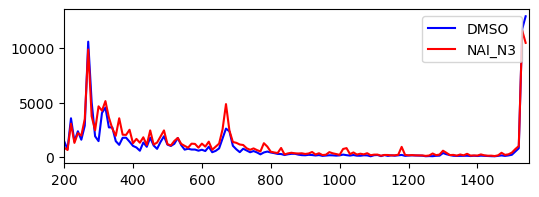

In [8]:
#画每个分群的count数
DMSON=[1474, 713, 3558, 1433, 2368, 1594, 2879, 10583, 5027, 1911, 1464, 4052, 4539, 2722, 2723, 1463, 1124, 1769, 1778, 1414, 1028, 880, 584, 1337, 946, 1780, 1062, 757, 1390, 1910, 1145, 1020, 1219, 1751, 1098, 684, 765, 694, 693, 587, 673, 556, 949, 446, 569, 797, 1700, 2611, 2364, 1038, 715, 453, 769, 608, 444, 554, 427, 253, 426, 507, 422, 365, 291, 280, 189, 259, 301, 305, 226, 180, 167, 208, 190, 148, 187, 113, 140, 167, 161, 135, 157, 230, 176, 140, 190, 129, 125, 166, 157, 76, 174, 191, 91, 187, 110, 159, 127, 163, 198, 113, 145, 157, 146, 127, 127, 77, 94, 83, 120, 132, 374, 260, 184, 122, 109, 111, 115, 124, 98, 121, 100, 131, 113, 95, 85, 75, 116, 153, 110, 151, 214, 507, 808, 11750, 12910]
NAIN=[878, 653, 3062, 1303, 2190, 1973, 3485, 9863, 3744, 2455, 4654, 4251, 5133, 3632, 2618, 1950, 3560, 2052, 2036,2506, 1272, 1668, 1318, 1815, 1108, 2447, 1149, 1331, 1897, 2446, 1188, 1068, 1478, 1755, 1212, 1028, 863, 1231, 1209, 866, 1235, 961, 1416, 673, 954, 1234, 2537, 4859, 2426, 1386, 1308, 1154, 1109, 810, 668, 797, 641, 519, 1273, 963, 492, 425, 373, 837, 244, 341, 397, 346, 330, 349, 286, 331, 469, 237, 354, 188, 217, 454, 347, 279, 207, 744, 823, 272, 426, 234, 310, 250, 357, 172, 225, 228, 127, 195, 192, 157, 167, 210, 937, 198, 164, 185, 159, 153, 153, 111, 147, 330, 177, 232, 586, 392, 185, 202, 135, 239, 159, 305, 136, 152, 140, 245, 162, 126, 132, 97, 160, 395, 203, 254, 411, 734, 1009, 11596, 10473]
intlength

plt.figure(figsize = (6,2))
sns.lineplot(x=intlength, y=DMSON, color='blue',label='DMSO')
sns.lineplot(x=intlength, y=NAIN, color='red',label='NAI_N3')
plt.xlim(200,1550)
plt.legend(loc="upper right")
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/ReadCount_lineplot.pdf")
#plt.close()

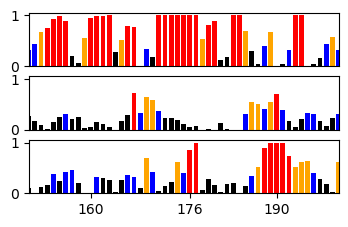

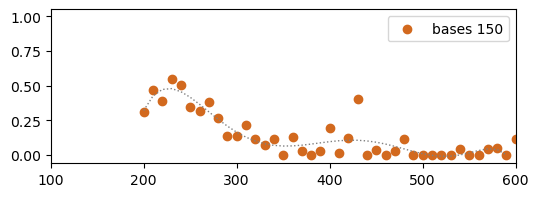

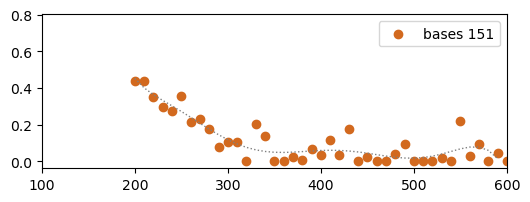

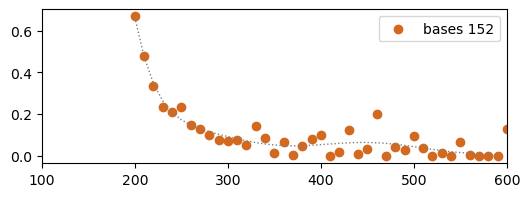

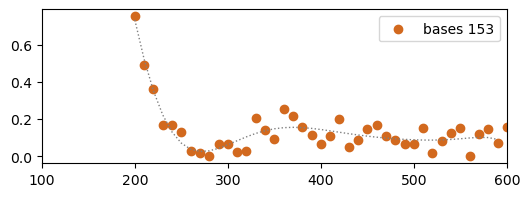

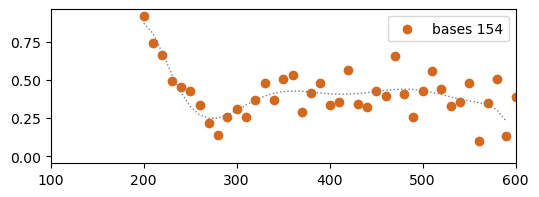

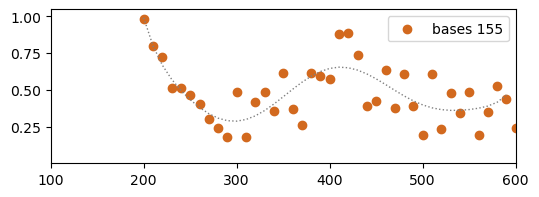

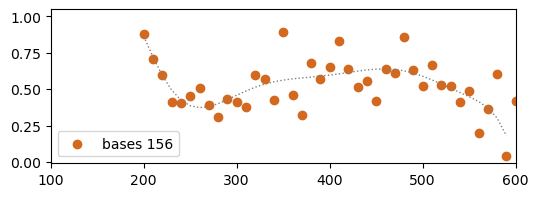

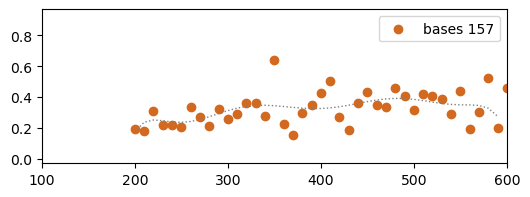

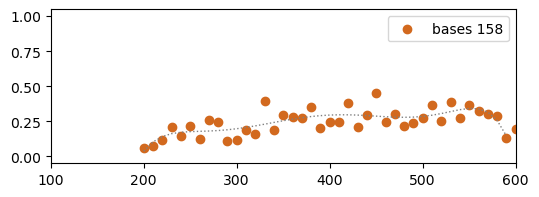

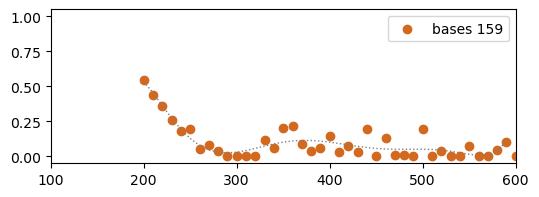

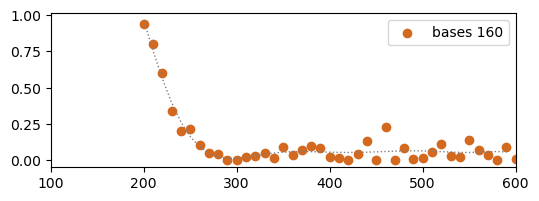

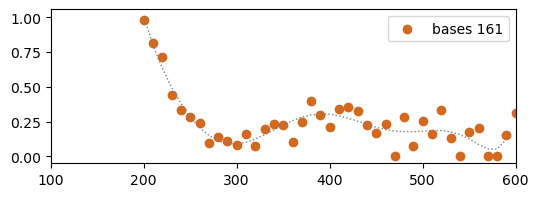

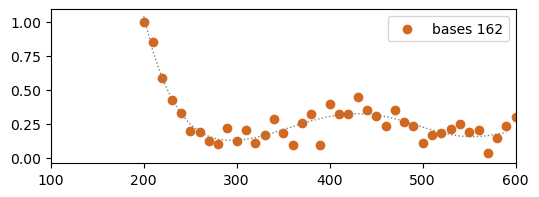

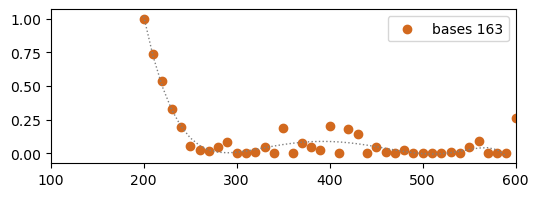

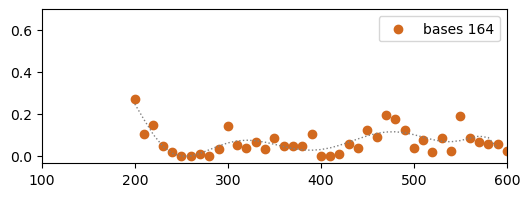

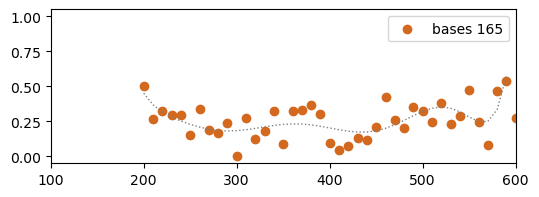

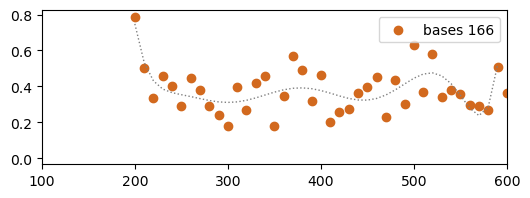

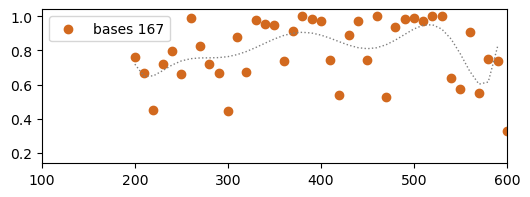

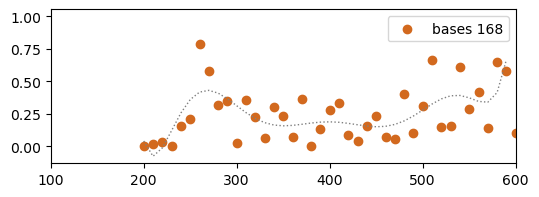

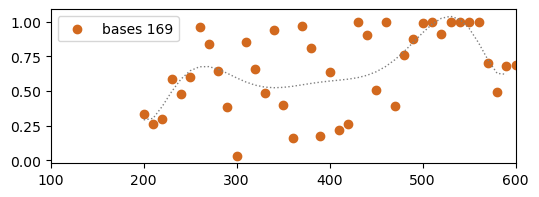

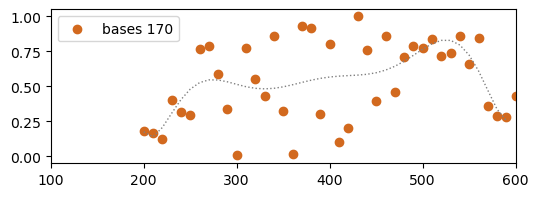

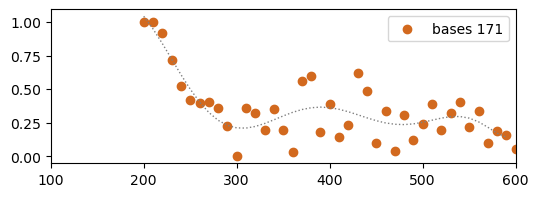

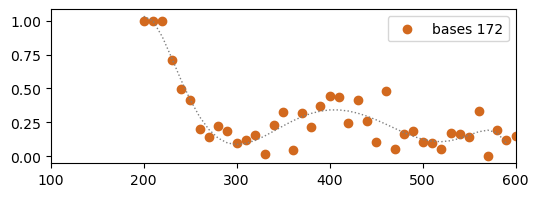

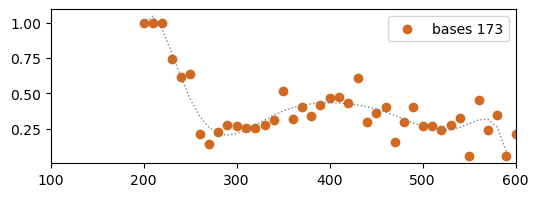

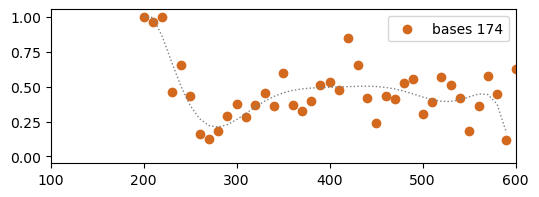

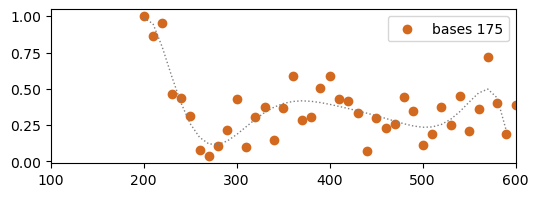

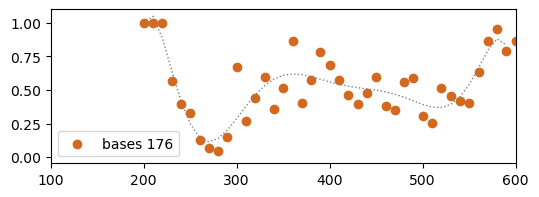

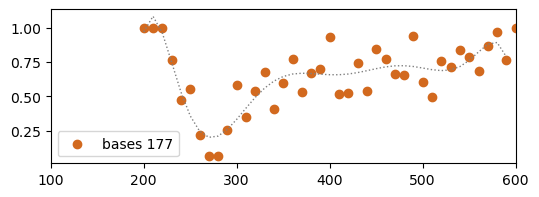

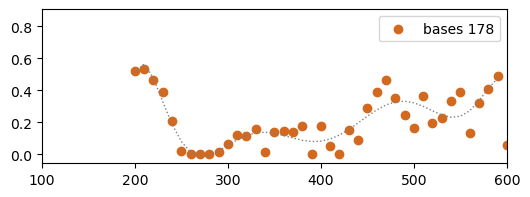

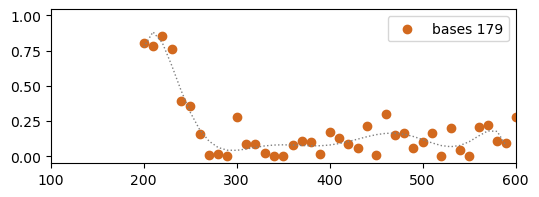

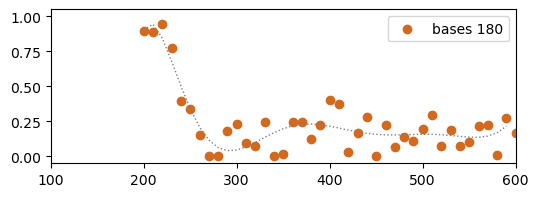

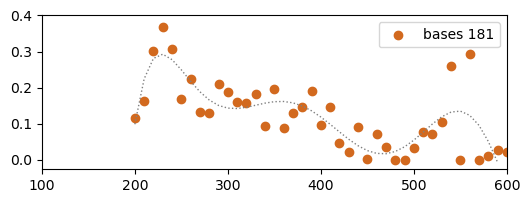

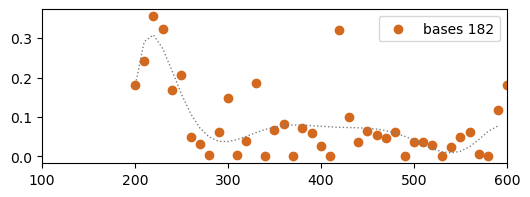

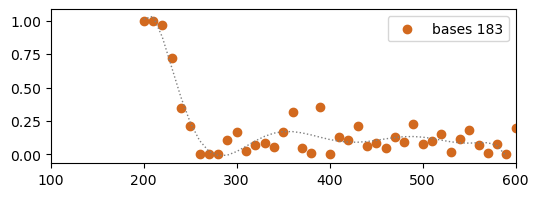

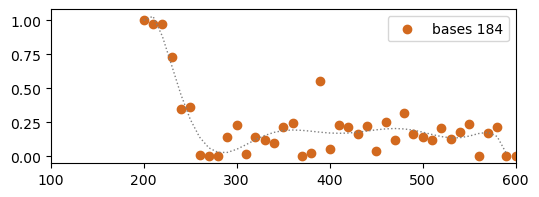

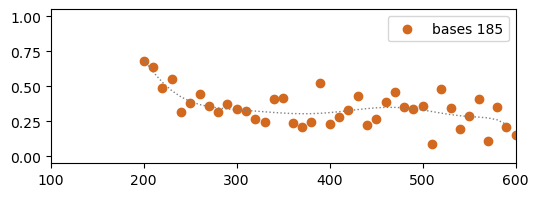

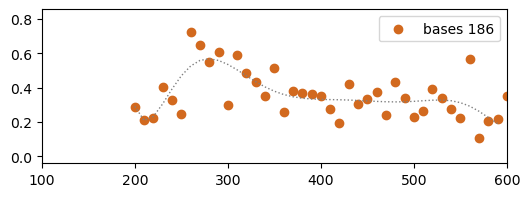

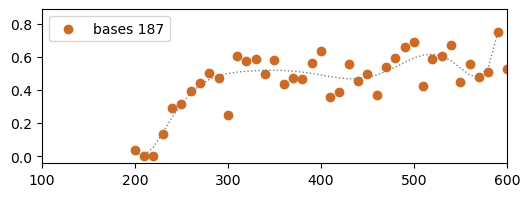

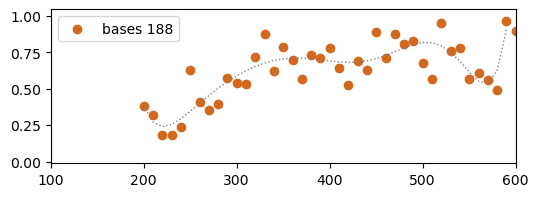

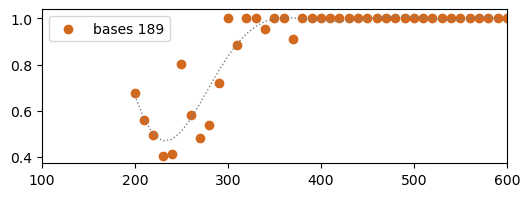

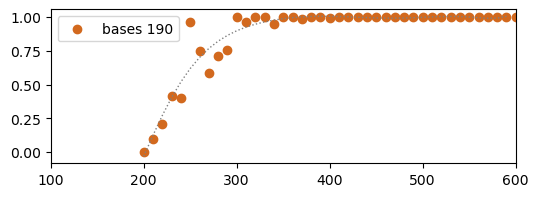

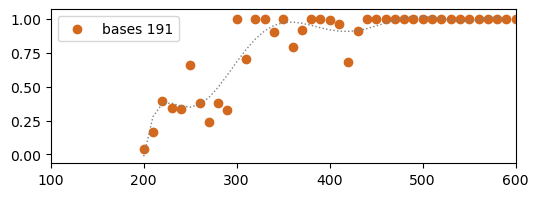

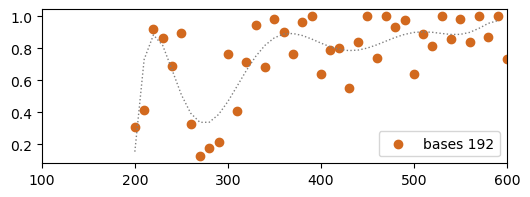

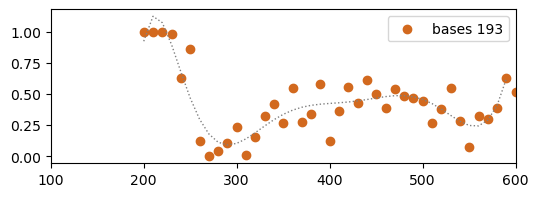

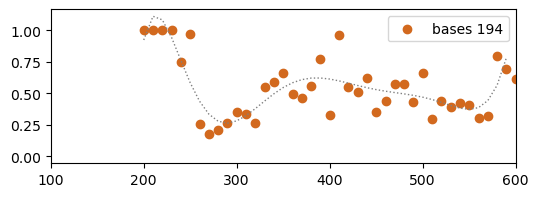

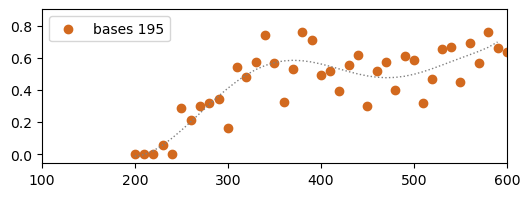

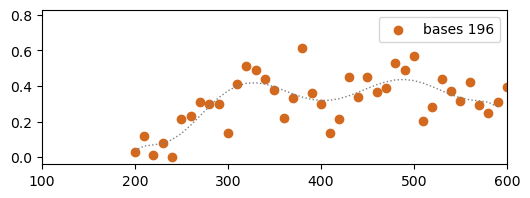

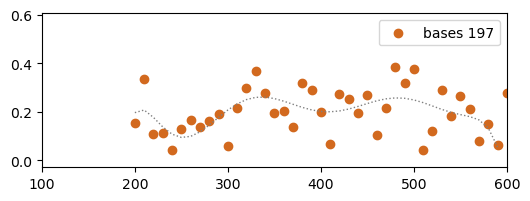

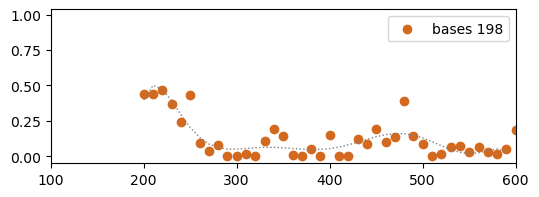

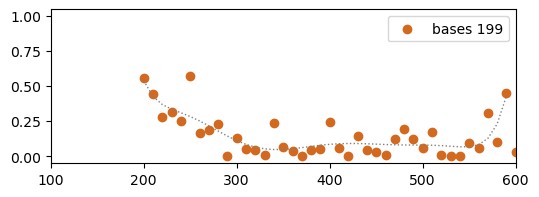

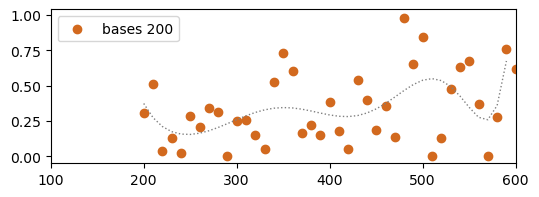

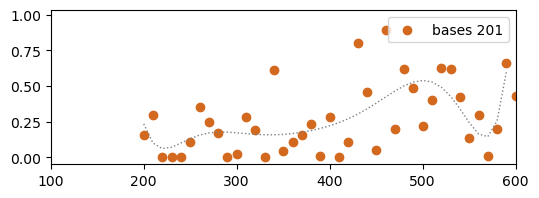

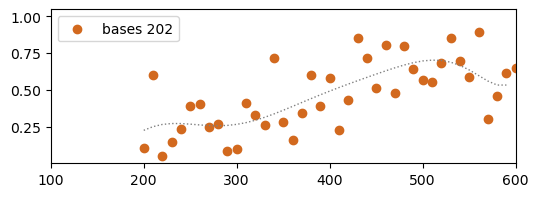

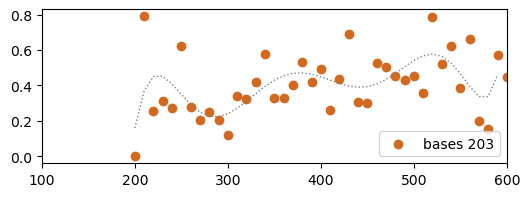

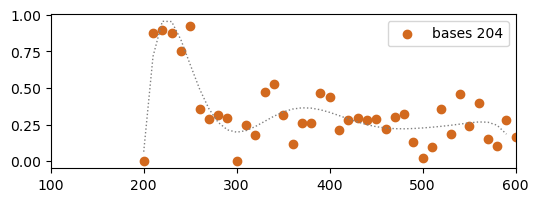

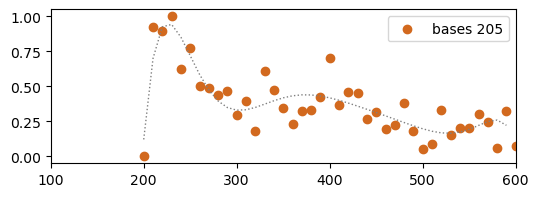

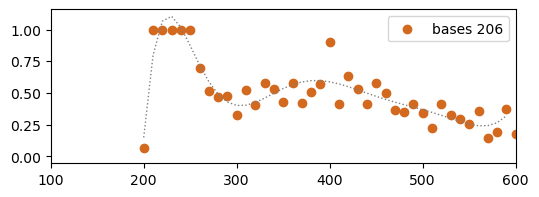

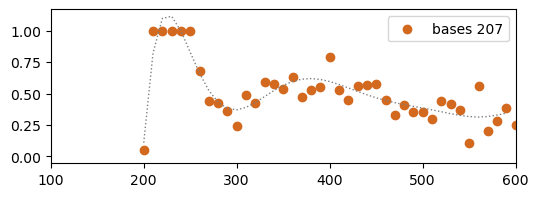

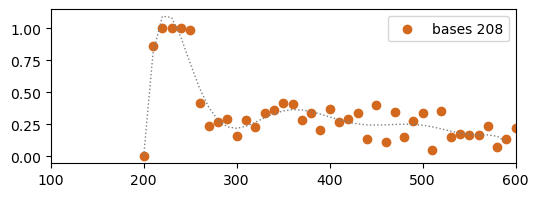

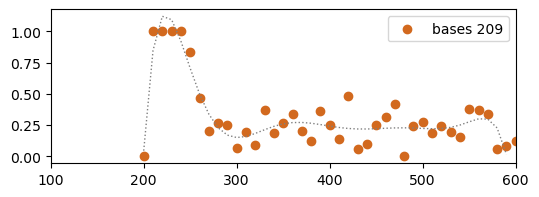

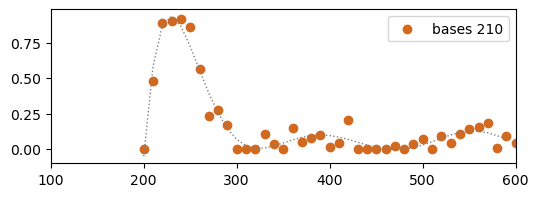

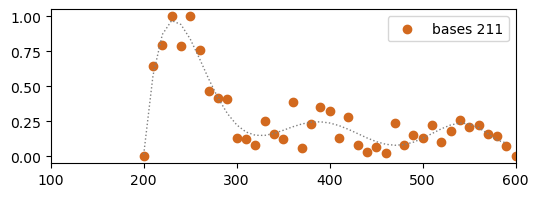

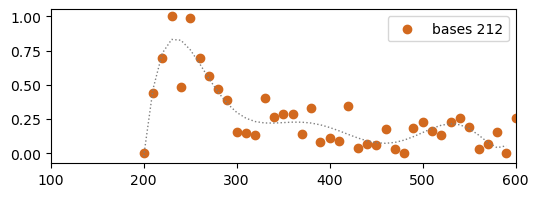

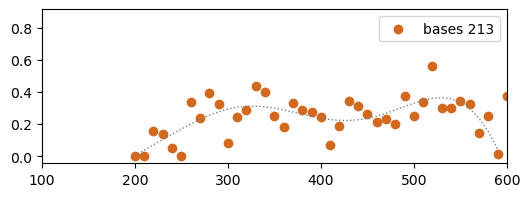

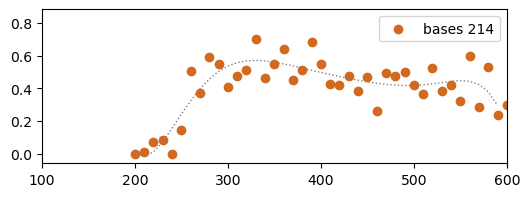

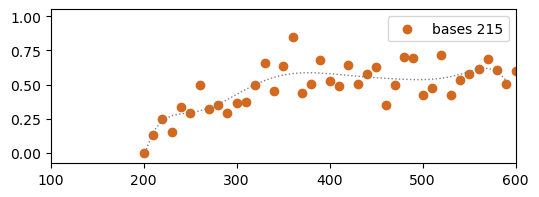

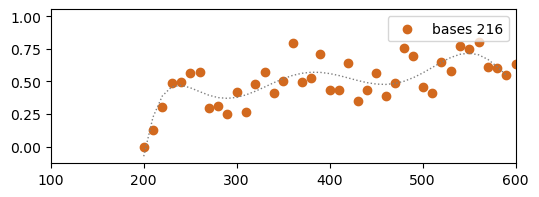

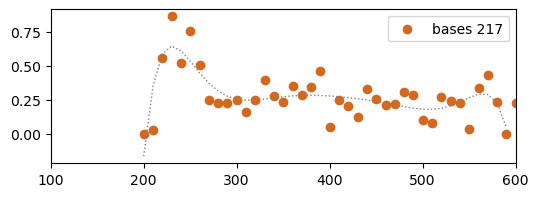

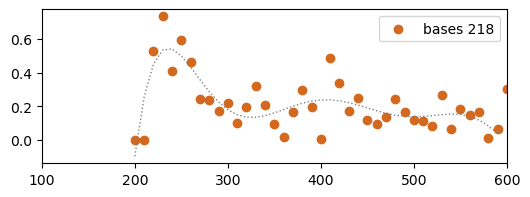

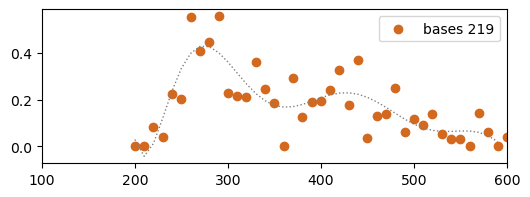

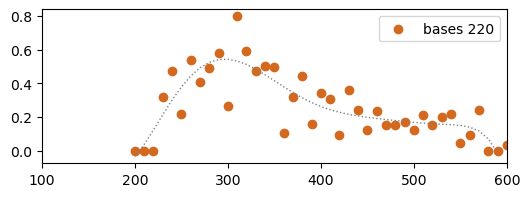

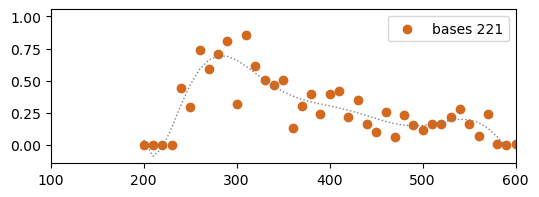

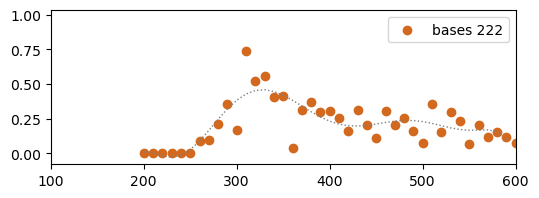

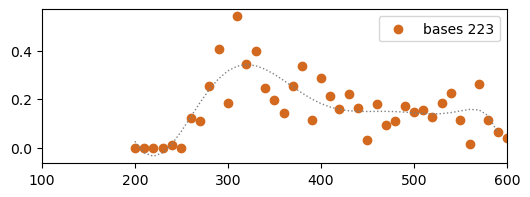

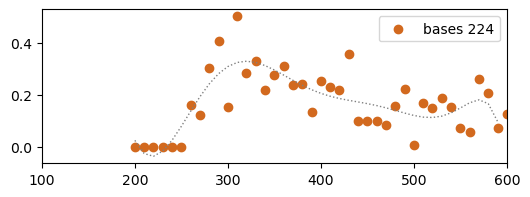

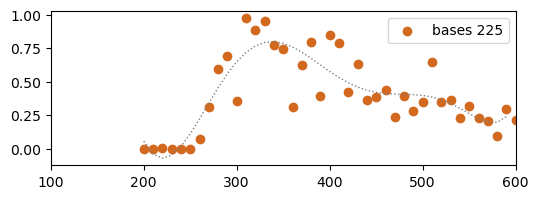

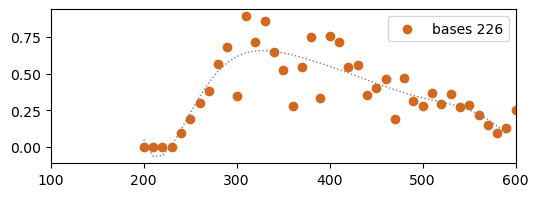

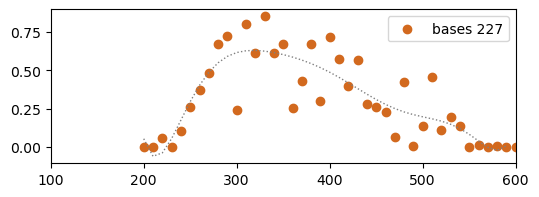

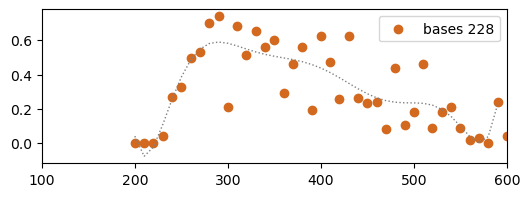

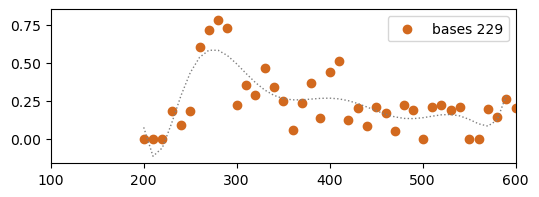

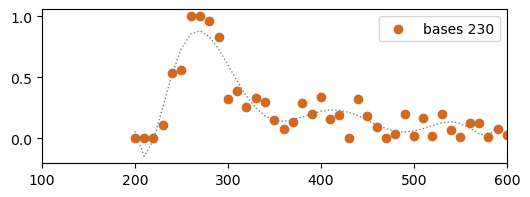

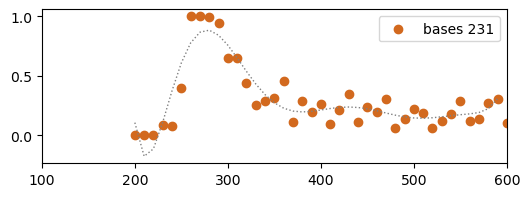

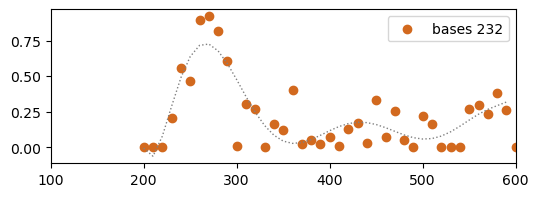

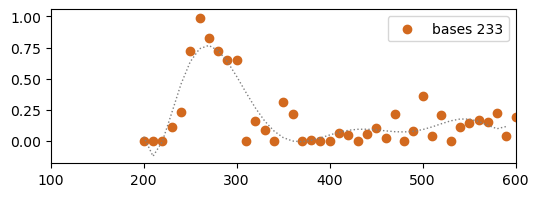

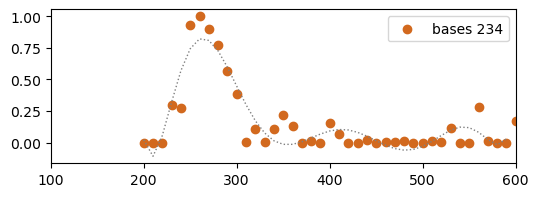

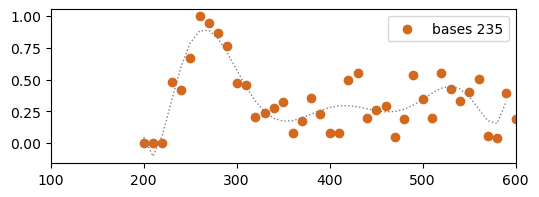

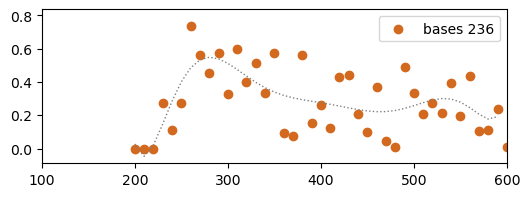

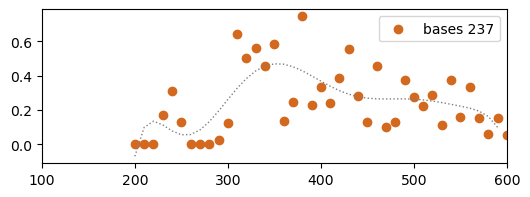

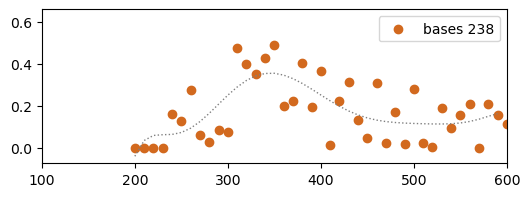

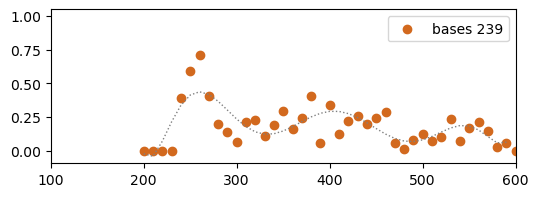

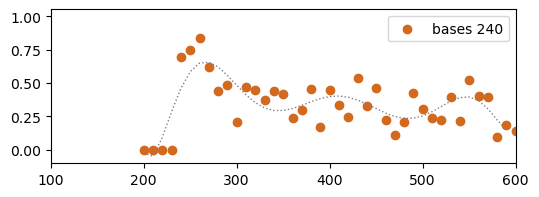

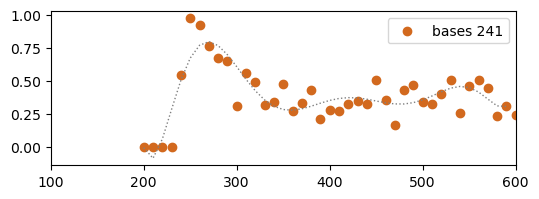

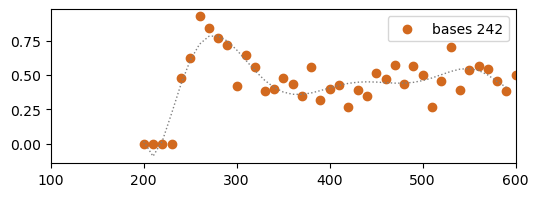

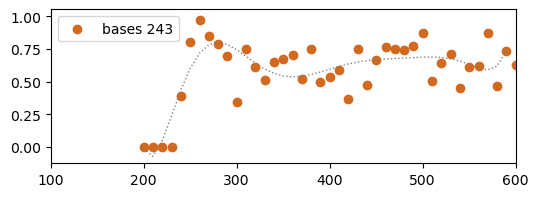

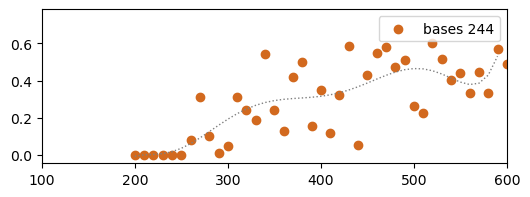

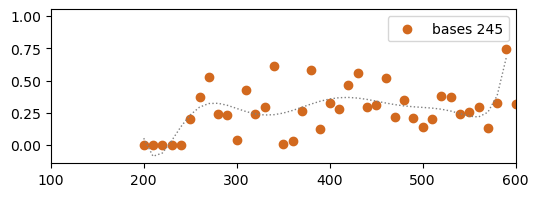

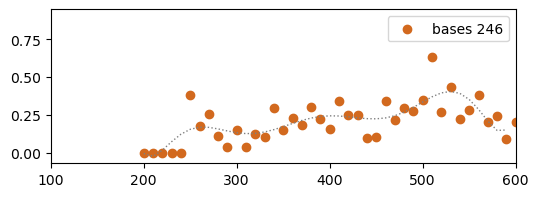

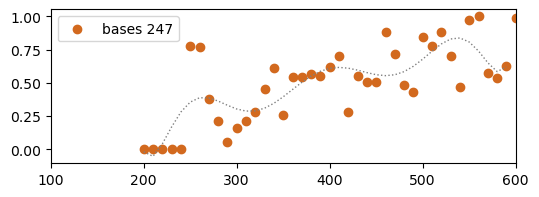

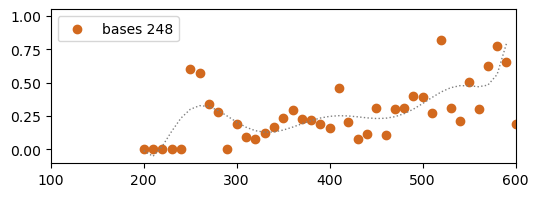

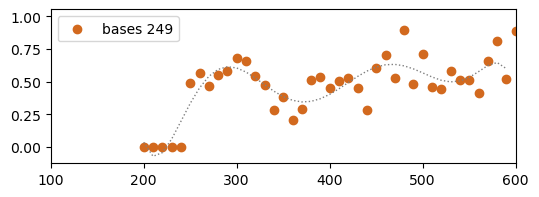

In [16]:
#合并后的数据分析

L1540score=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/meanScores/new1540.score',sep='\t',index_col=0)
Cupinedotfile=General.load_dot('/data1/huangyong/Project/Nanopore/16S/16S_T.dot')
Cupineseq=Cupinedotfile['16S'][0]
Cupinedot=Cupinedotfile['16S'][1]
posListCupine=[i for i in range(1,len(Cupineseq)+1)]
X=heatmap.T.fillna(0.0)
#print(X)
end=400
fig = plt.figure(figsize = (4,4))

ax = fig.add_subplot(5,1,1) 
plt.bar(posListCupine[0:end], X.loc[200].tolist()[0:end], color =color_SHAPE(X.loc[200].tolist()[0:end]) ,label='200')
plt.xticks([])
plt.xlim(150,200)

ax = fig.add_subplot(5,1,2) 
plt.bar(posListCupine[0:end], X.loc[280].tolist()[0:end], color =color_SHAPE(X.loc[280].tolist()[0:end]) ,label='300')
plt.xticks([])
plt.xlim(150,200)

ax = fig.add_subplot(5,1,3) 
plt.bar(posListCupine[0:end], X.loc[600].tolist()[0:end], color =color_SHAPE(X.loc[600].tolist()[0:end]) ,label='400')
plt.xlim(150,200)
#plt.legend()
plt.xticks([160,176,190])
plt.show()

#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/3个点位score.pdf")
#plt.close()

for i in range(150,250):
    plt.figure(figsize=(6,2))
    plt.scatter(intlength,X[i].tolist(),c='Chocolate',marker='o',linewidth=1,label=f'bases {i}')
    plt.xlim(100,600)
    plt.legend(fontsize=10)
    poly = np.polyfit(intlength[0:40], X[i].tolist()[0:40], deg=8)
    y_value = np.polyval(poly, intlength[0:40])
    plt.plot(intlength[0:40], y_value,c='gray',linestyle=':',linewidth=1)
    plt.show()

In [17]:
bias=2
L200_dot= Structure.predict_structure(Cupineseq[0+bias:200+bias],X.loc[200].tolist()[0:200],si=-0.6,sm=2.0,md=100,method='RNAfold')
L300_dot= Structure.predict_structure(Cupineseq[0+bias:300+bias],X.loc[300].tolist()[0:300],si=-0.6,sm=1.8,md=100,method='RNAfold')
L400_dot= Structure.predict_structure(Cupineseq[0+bias:400+bias],X.loc[600].tolist()[0:400],si=-0.6,sm=1.8,md=100,method='RNAfold')

CMD_200=Visual.Plot_RNAStructure_Shape(Cupineseq[0+bias:200+bias], L200_dot, X.loc[200].tolist()[0:200],mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=3+bias, title = ("200_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMD_200)

CMD_300=Visual.Plot_RNAStructure_Shape(Cupineseq[0+bias:300+bias], L300_dot, X.loc[300].tolist()[0:300],mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=3+bias, title = ("300_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMD_300)

CMD_400=Visual.Plot_RNAStructure_Shape(Cupineseq[0+bias:400+bias], L400_dot, X.loc[400].tolist()[0:400],mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=3+bias, title = ("400_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMD_400)

java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN AUCGGAGAGUUUGAUCCUGGCUCAGGACGAACGCUGGCGGCGUGCCUAAUACAUGCAAGUCGAGCGGACAGAUGGGAGCUUGCUCCCUGAUGUUAGCGGCGGACGGGUGAGUAACACGUGGGUAACCUGCCUGUAAGACUGGGAUAACUCCGGGAAACCGGGGCUAAUACCGGAUGGUUGUUUGAACCGCAUGGUUCAAA -structureDBN ".((((...(((((.(((((...)))))))))).))))((((.(((.........))).)))).((.((((...(((((....)))))...)))).))...((((..((((((.(((.(((((...))))).)))...)))((.....((((((....))))))......))....((((.....)))).))).))))..." -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "99,137,143,144,153,154,155,156,160,161,162,163,166,167,171,172,173,174,175,176,177,179,180,183,184,193,194" -applyBasesStyle2on "37,40,42,45,49,50,51,52,53,96,97,98,124,125,136,142,146,147,152,159,165,178,185,189,199" -applyBasesStyle3on "30,31,32,36,38,39,41,43,44,46,48,84,85,1

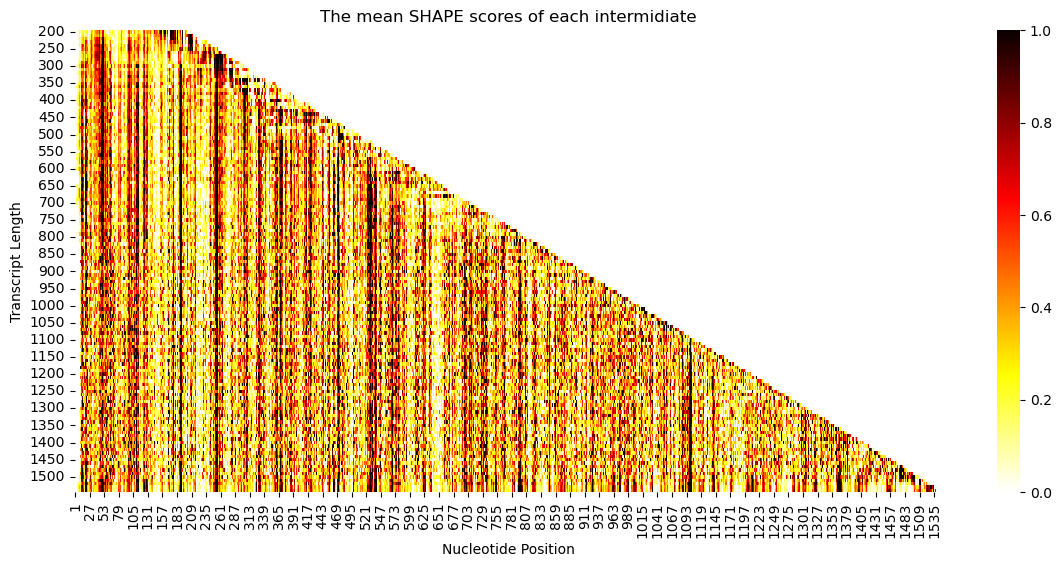

In [5]:

#画heatmap
intlength=[i*10 for i in range(20,155)]
outdir='/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/meanScores'
for row in intlength:
    shape=pd.read_csv(outdir+'/new'+str(row)+'.score',sep='\t',index_col=0)
    if row==200:
        heatmap=shape
    else:
        heatmap=pd.concat([heatmap,shape],axis=1)
heatmap.columns=intlength

plt.figure(figsize=(14,6))
sns.heatmap(heatmap.T, cmap='hot_r', annot=False)
plt.xlabel('Nucleotide Position')
plt.ylabel('Transcript Length')
plt.title(f'The mean SHAPE scores of each intermidiate')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/meanScores/SHAPE score heatmap_new.pdf")
#plt.close()

In [ ]:
#向结构添加全长时的score
def AddSHAPEtoSVGfile(SHAPEdict, shift,inSVG, outSVG):
	#SHAPEdict是字典格式的shapescore，如果不是字典可以先用to_dict()转成字典
	#shift是指shapescore和结构上的碱基有错位的情况。
	#inSVG是下载的svg格式的结构文件
    import re
    out=open(outSVG,'w')
    for line in open(inSVG):
        if 'title><text' in line and not 'numbering-label' in line:
            out.write(line)
            p=re.findall(r'>\d+',line)[0][1:]
            if int(p) in SHAPEdict.keys() and int(p) > shift:
                cor=SHAPEdict[int(p)-shift]*255
                x=re.findall(r'x=\".*?\"',line)[0]
                xp=x[3:-1]
                y=re.findall(r'y=\".*?\"',line)[0]
                yp=y[3:-1]
                temp=f'<g><circle cx="{xp}" cy="{yp}" r="2.8" stroke="none" stroke-width="0.2" fill="rgb({cor}, 0, 0)"/></g>\n'
                out.write(temp)
        else:
            out.write(line)
    out.close()

L1540score=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/meanScores/1540.score',sep='\t',index_col=0)
AddSHAPEtoSVGfile(L1540score.to_dict()['score'],2,'/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/in16S.svg','/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/1540.score.16S.svg')
#计算AUC
Cupinedotfile=General.load_dot('/data1/huangyong/Project/Nanopore/16S/16S_T.dot')
Cupineseq=Cupinedotfile['16S'][0]
Cupinedot=Cupinedotfile['16S'][1]
posListCupine=[i for i in range(1,len(Cupineseq)+1)]
General.calc_AUC_v2(Cupinedot[3:1548], L1540score[0:1546])


In [23]:
#分析自产16S数据中存在异质性结构的位点
BitvectorL270=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_270.event.profile.vect',sep='\t',index_col=0)
BitvectorL300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_300.event.profile.vect',sep='\t',index_col=0)
BitvectorL310=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_310.event.profile.vect',sep='\t',index_col=0)
BitvectorL320=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_320.event.profile.vect',sep='\t',index_col=0)
BitvectorL670=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_670.event.profile.vect',sep='\t',index_col=0)
#BitvectorL1040=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1040.event.profile.vect',sep='\t',index_col=0)
#BitvectorL1300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1300.event.profile.vect',sep='\t',index_col=0)
BitvectorL1530=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1530.event.profile.vect',sep='\t',index_col=0)
BitvectorL1540=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1540.event.profile.vect',sep='\t',index_col=0)

DMSOL270=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_270.event.profile.vect',sep='\t',index_col=0)
DMSOL300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_300.event.profile.vect',sep='\t',index_col=0)
DMSOL310=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_310.event.profile.vect',sep='\t',index_col=0)
DMSOL320=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_320.event.profile.vect',sep='\t',index_col=0)
DMSOL670=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_670.event.profile.vect',sep='\t',index_col=0)
#DMSOL1040=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1040.event.profile.vect',sep='\t',index_col=0)
#DMSOL1300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1300.event.profile.vect',sep='\t',index_col=0)
DMSOL1530=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1530.event.profile.vect',sep='\t',index_col=0)
DMSOL1540=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1540.event.profile.vect',sep='\t',index_col=0)

Cupinedotfile=General.load_dot('/data1/huangyong/Project/Nanopore/16S/16S_T.dot')
Cupineseq=Cupinedotfile['16S'][0]
Cupinedot=Cupinedotfile['16S'][1]
posListCupine=[i for i in range(1,len(Cupineseq)+1)]

[(0, 5324), (1, 4474)]


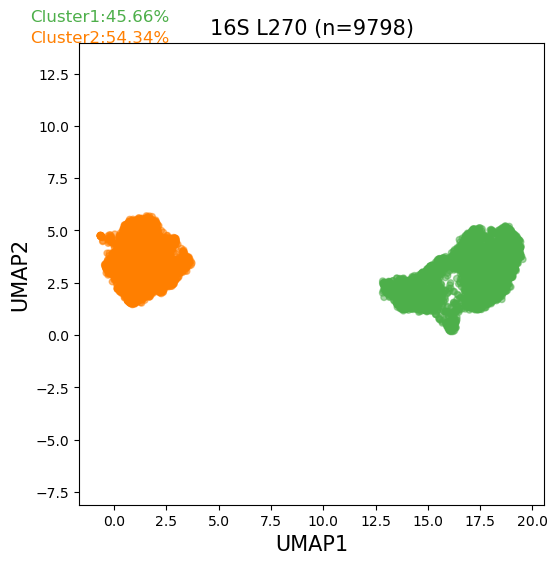

In [27]:
L270_classdf=BitvectorL270
UP = umap.UMAP(n_components=2)
L270_UMAP = pd.DataFrame(UP.fit_transform(L270_classdf),columns = ['UMAP1', 'UMAP2'])
#L270_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L270_UMAP)
#L270_clust_ids =L270_clustering.labels_.tolist()
L270_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L270_UMAP)
L270_clust_ids = L270_clustering.predict(L270_UMAP).tolist()
print(Counter(L270_clust_ids).most_common(int(3)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L270_number_c1=L270_clust_ids.count(1)/len(L270_clust_ids)
L270_number_c2=L270_clust_ids.count(0)/len(L270_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L270_UMAP['UMAP1'], L270_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L270_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,15,'Cluster1:{:.2%}'.format(L270_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,14,'Cluster2:{:.2%}'.format(L270_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L270 (n={len(L270_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/270.PCA.pdf")
#plt.close()
L270_C1=L270_classdf.iloc[get_index(L270_clust_ids,1),:]
L270_C2=L270_classdf.iloc[get_index(L270_clust_ids,0),:]


[(0, 3387), (1, 1227)]


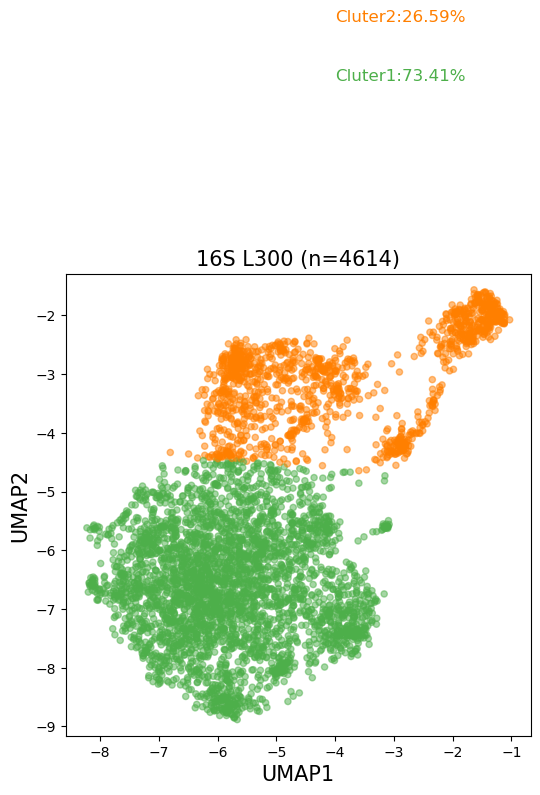

In [28]:
L300_classdf=BitvectorL300
UP = umap.UMAP(n_components=2,n_neighbors=30)
L300_UMAP = pd.DataFrame(UP.fit_transform(L300_classdf),columns = ['UMAP1', 'UMAP2'])
#L300_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L300_UMAP)
#L300_clust_ids =L300_clustering.labels_.tolist()
L300_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L300_UMAP)
L300_clust_ids = L300_clustering.predict(L300_UMAP).tolist()
print(Counter(L300_clust_ids).most_common(int(3)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L300_number_c1=L300_clust_ids.count(0)/len(L300_clust_ids)
L300_number_c2=L300_clust_ids.count(1)/len(L300_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L300_UMAP['UMAP1'], L300_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L300_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,2,'Cluter1:{:.2%}'.format(L300_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,3,'Cluter2:{:.2%}'.format(L300_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L300 (n={len(L300_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/300.PCA.pdf")
#plt.close()
L300_C1=L300_classdf.iloc[get_index(L300_clust_ids,0),:]
L300_C2=L300_classdf.iloc[get_index(L300_clust_ids,1),:]
L300_score1=CalculateSHAPEFromBitvector_control(L300_C1,DMSOL300,1)
L300_score2=CalculateSHAPEFromBitvector_control(L300_C2,DMSOL300,1)


[(0, 2702), (1, 2390)]


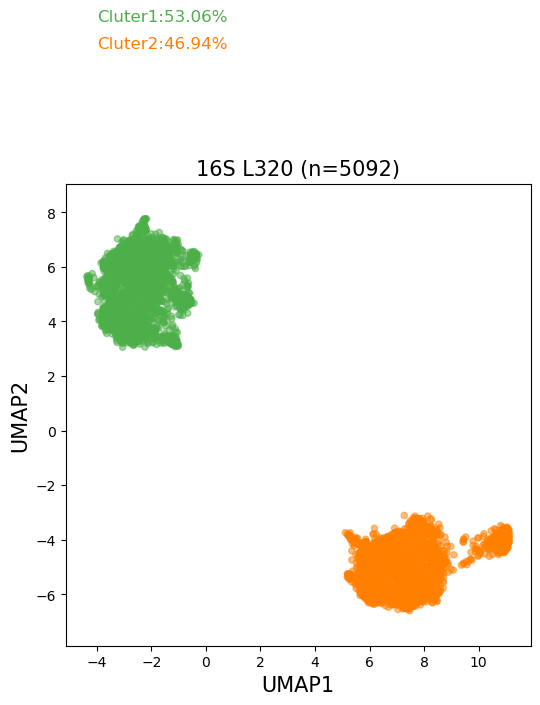

In [29]:
L320_classdf=BitvectorL320
UP = umap.UMAP(n_components=2)
L320_UMAP = pd.DataFrame(UP.fit_transform(L320_classdf),columns = ['UMAP1', 'UMAP2'])
#L320_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L320_UMAP)
#L320_clust_ids =L320_clustering.labels_.tolist()
L320_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L320_UMAP)
L320_clust_ids = L320_clustering.predict(L320_UMAP).tolist()
print(Counter(L320_clust_ids).most_common(int(3)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L320_number_c1=L320_clust_ids.count(0)/len(L320_clust_ids)
L320_number_c2=L320_clust_ids.count(1)/len(L320_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L320_UMAP['UMAP1'], L320_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L320_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,15,'Cluter1:{:.2%}'.format(L320_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,14,'Cluter2:{:.2%}'.format(L320_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L320 (n={len(L320_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/320.PCA.pdf")
#plt.close()
L320_C1=L320_classdf.iloc[get_index(L320_clust_ids,0),:]
L320_C2=L320_classdf.iloc[get_index(L320_clust_ids,1),:]


<Figure size 400x400 with 0 Axes>

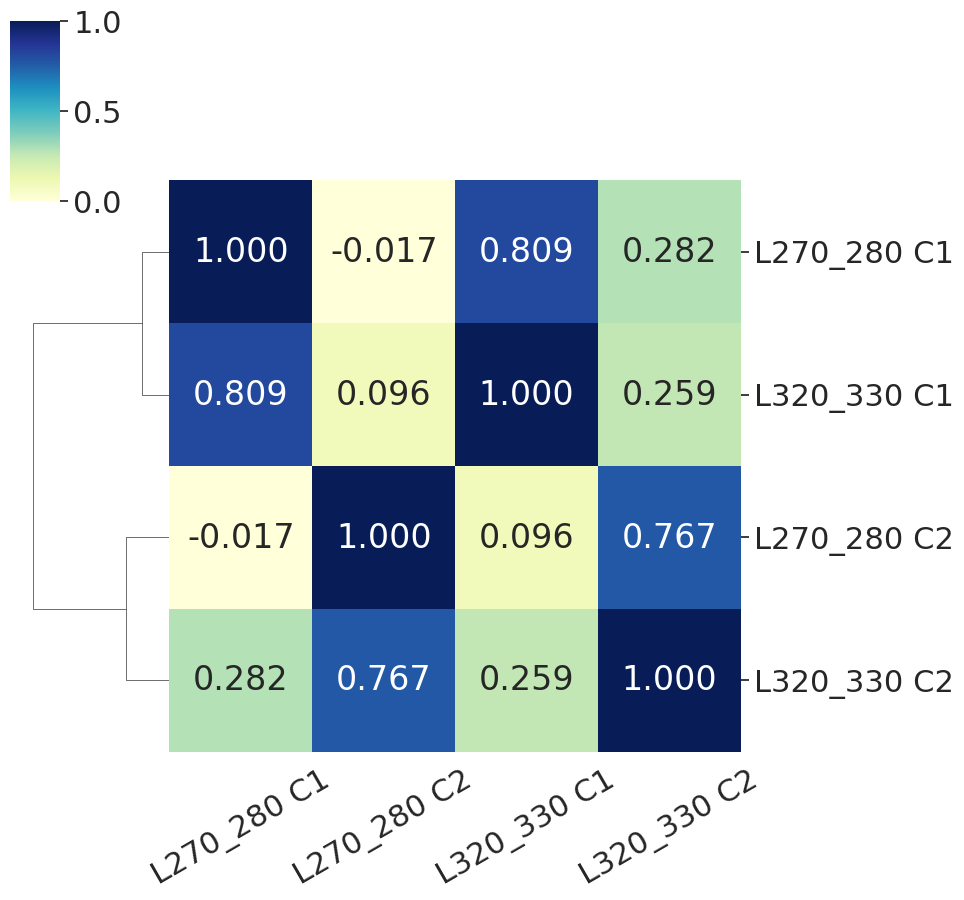

In [33]:
#计算各个cluster间的相关性
L270_score1=CalculateSHAPEFromBitvector_control(L270_C1,DMSOL270,1)
L270_score2=CalculateSHAPEFromBitvector_control(L270_C2,DMSOL270,1)
L320_score1=CalculateSHAPEFromBitvector_control(L320_C1,DMSOL320,1)
L320_score2=CalculateSHAPEFromBitvector_control(L320_C2,DMSOL320,1)


plt.close()
scorelist=[L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270]]
namelists=['L270_280 C1','L270_280 C2','L320_330 C1','L320_330 C2']
n=4
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)

plt.figure(figsize=(4,4))
hm=sns.clustermap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f",vmin=0, vmax=1,col_cluster=False)
sns.set(font_scale=2)#plt.title("Pearson Correlation coefficient of 16S")
plt.setp(hm.ax_heatmap.get_xticklabels(), rotation=30) 
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/270VS320.PCC.pdf")
#plt.close()

[(0, 4164), (1, 656)]


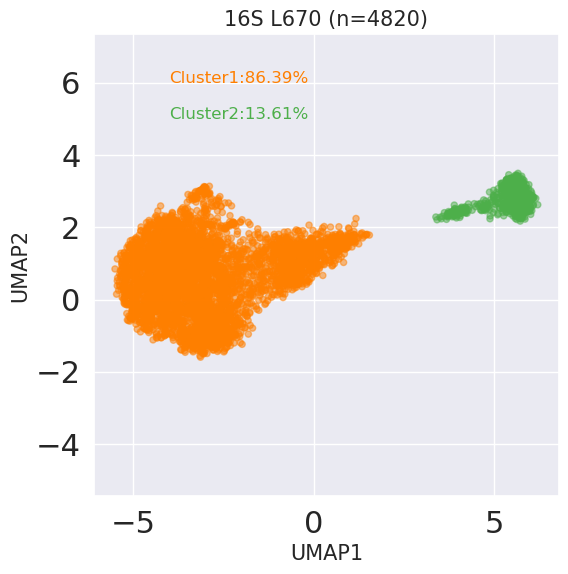

In [34]:
L670_classdf=BitvectorL670
UP = umap.UMAP(n_components=2)
L670_UMAP = pd.DataFrame(UP.fit_transform(L670_classdf),columns = ['UMAP1', 'UMAP2'])
#L670_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L670_UMAP)
#L670_clust_ids =L670_clustering.labels_.tolist()
L670_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L670_UMAP)
L670_clust_ids = L670_clustering.predict(L670_UMAP).tolist()
print(Counter(L670_clust_ids).most_common(int(3)))
cluster_color = { 1: '#4daf4a', 0: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L670_number_c1=L670_clust_ids.count(0)/len(L670_clust_ids)
L670_number_c2=L670_clust_ids.count(1)/len(L670_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L670_UMAP['UMAP1'], L670_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L670_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,6,'Cluster1:{:.2%}'.format(L670_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,5,'Cluster2:{:.2%}'.format(L670_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L670 (n={len(L670_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/670.PCA.pdf")
#plt.close()
L670_C1=L670_classdf.iloc[get_index(L670_clust_ids,0),:]
L670_C2=L670_classdf.iloc[get_index(L670_clust_ids,1),:]

L670_score1=CalculateSHAPEFromBitvector_control(L670_C1,DMSOL670,1)
L670_score2=CalculateSHAPEFromBitvector_control(L670_C2,DMSOL670,1)

<Figure size 400x400 with 0 Axes>

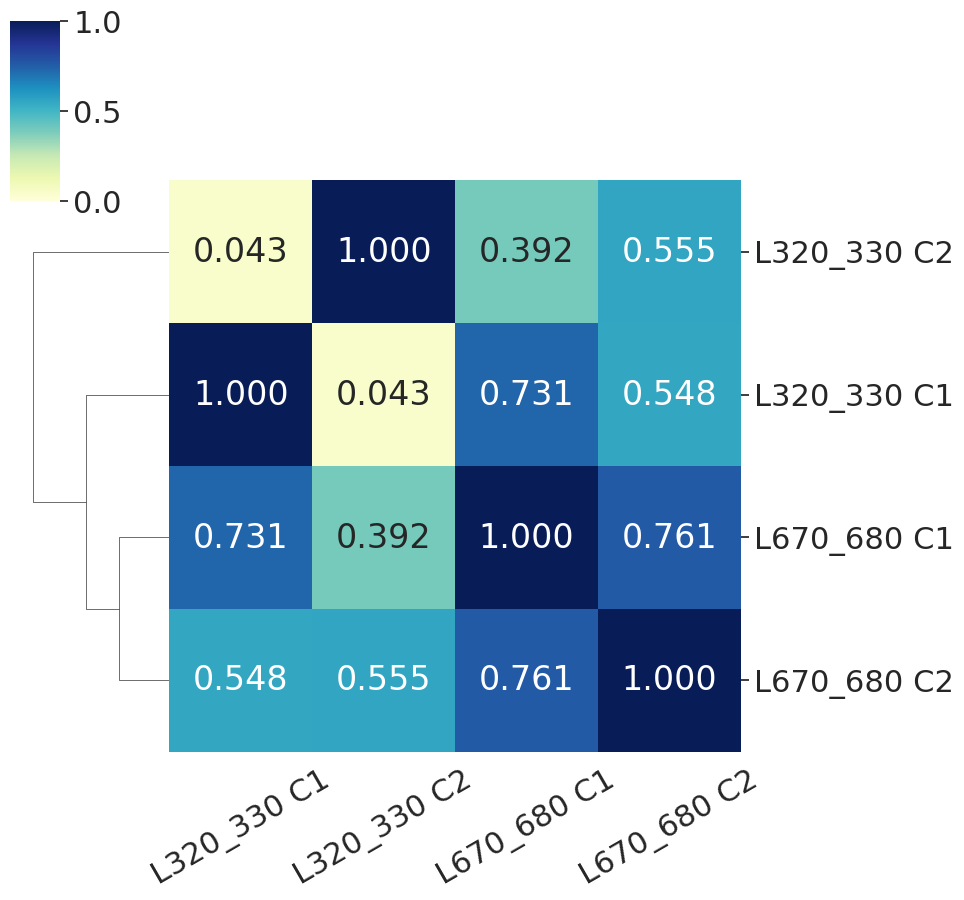

In [35]:
scorelist=[L320_score1[0:320],L320_score2[0:320],L670_score1[0:320],L670_score2[0:320]]
namelists=['L320_330 C1','L320_330 C2','L670_680 C1','L670_680 C2']
n=4
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.spearmanr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)

plt.figure(figsize=(4,4))
hm=sns.clustermap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f",vmin=0, vmax=1,col_cluster=False)
sns.set(font_scale=2)#plt.title("Pearson Correlation coefficient of 16S")
plt.setp(hm.ax_heatmap.get_xticklabels(), rotation=30) 
plt.rcParams['pdf.fonttype'] = 42
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/320VS670.PCC.pdf")
#plt.close()

[(0, 11454)]


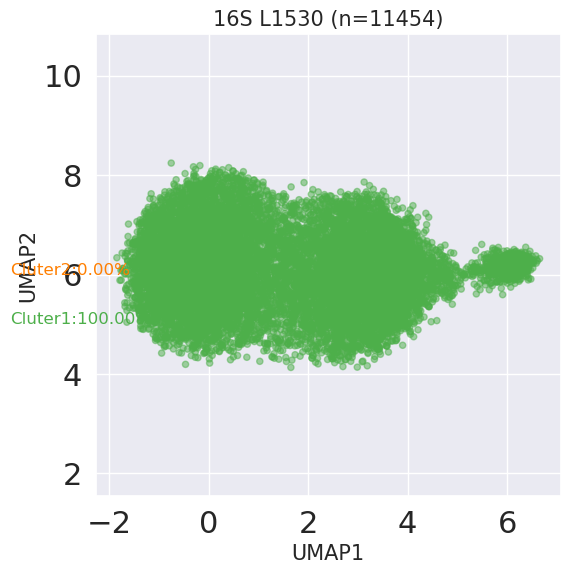

In [36]:
L1530_classdf=BitvectorL1530
UP = umap.UMAP(n_components=2)
L1530_UMAP = pd.DataFrame(UP.fit_transform(L1530_classdf),columns = ['UMAP1', 'UMAP2'])
#L1530_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L1530_UMAP)
#L1530_clust_ids =L1530_clustering.labels_.tolist()
L1530_clustering =GaussianMixture(n_components =1,covariance_type='full',random_state=1).fit(L1530_UMAP)
L1530_clust_ids = L1530_clustering.predict(L1530_UMAP).tolist()
print(Counter(L1530_clust_ids).most_common(int(3)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L1530_number_c1=L1530_clust_ids.count(0)/len(L1530_clust_ids)
L1530_number_c2=L1530_clust_ids.count(1)/len(L1530_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L1530_UMAP['UMAP1'], L1530_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L1530_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,5,'Cluter1:{:.2%}'.format(L1530_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,6,'Cluter2:{:.2%}'.format(L1530_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L1530 (n={len(L1530_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/1530.PCA.pdf")
#plt.close()

L1530_C1=L1530_classdf.iloc[get_index(L1530_clust_ids,0),:]

L1530_score1=CalculateSHAPEFromBitvector_control(L1530_C1,DMSOL1530,1)


[(0, 10359)]


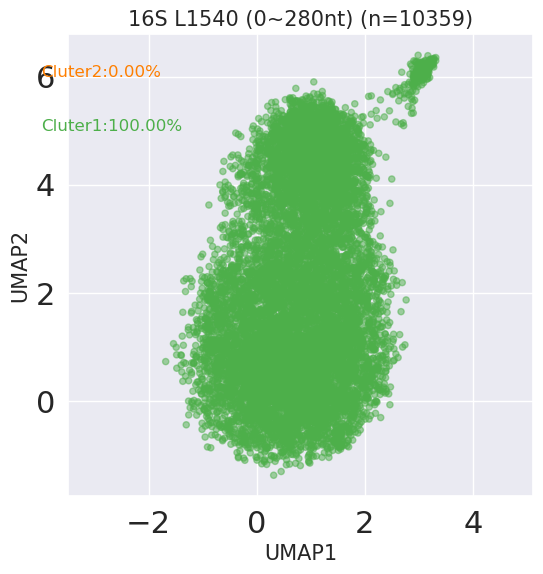

In [38]:
L1540_classdf=BitvectorL1540
UP = umap.UMAP(n_components=2)
L1540_UMAP = pd.DataFrame(UP.fit_transform(L1540_classdf),columns = ['UMAP1', 'UMAP2'])
#L1540_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L1540_UMAP)
#L1540_clust_ids =L1540_clustering.labels_.tolist()
L1540_clustering =GaussianMixture(n_components =1,covariance_type='full',random_state=1).fit(L1540_UMAP)
L1540_clust_ids = L1540_clustering.predict(L1540_UMAP).tolist()
print(Counter(L1540_clust_ids).most_common(int(3)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L1540_number_c1=L1540_clust_ids.count(0)/len(L1540_clust_ids)
L1540_number_c2=L1540_clust_ids.count(1)/len(L1540_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L1540_UMAP['UMAP1'], L1540_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L1540_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,5,'Cluter1:{:.2%}'.format(L1540_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,6,'Cluter2:{:.2%}'.format(L1540_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L1540 (0~280nt) (n={len(L1540_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/1540.PCA.pdf")
#plt.close()

L1540_C1=L1540_classdf.iloc[get_index(L1540_clust_ids,0),:]

L1540_score1=CalculateSHAPEFromBitvector_control(L1540_C1,DMSOL1540,1)


In [82]:
plt.style.use('default')
plt.rcdefaults()


<Figure size 400x400 with 0 Axes>

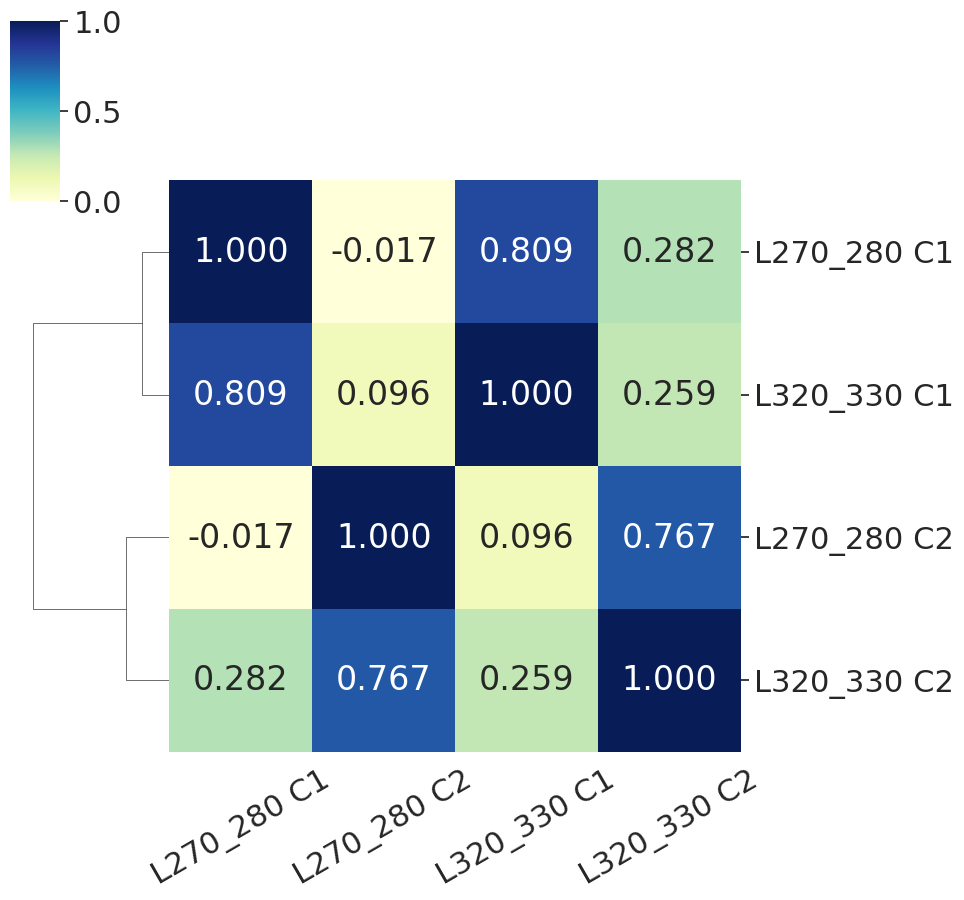

In [80]:
#计算各个cluster间的相关性
scorelist=[L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270]]
namelists=['L270_280 C1','L270_280 C2','L320_330 C1','L320_330 C2']
n=4
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)

plt.figure(figsize=(4,4))
hm=sns.clustermap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f",vmin=0, vmax=1,col_cluster=False)
plt.setp(hm.ax_heatmap.get_xticklabels(), rotation=30) 
#plt.rcParams['pdf.fonttype'] = 42
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/670VS1530.PCC.pdf")
#plt.close()()

<Figure size 400x400 with 0 Axes>

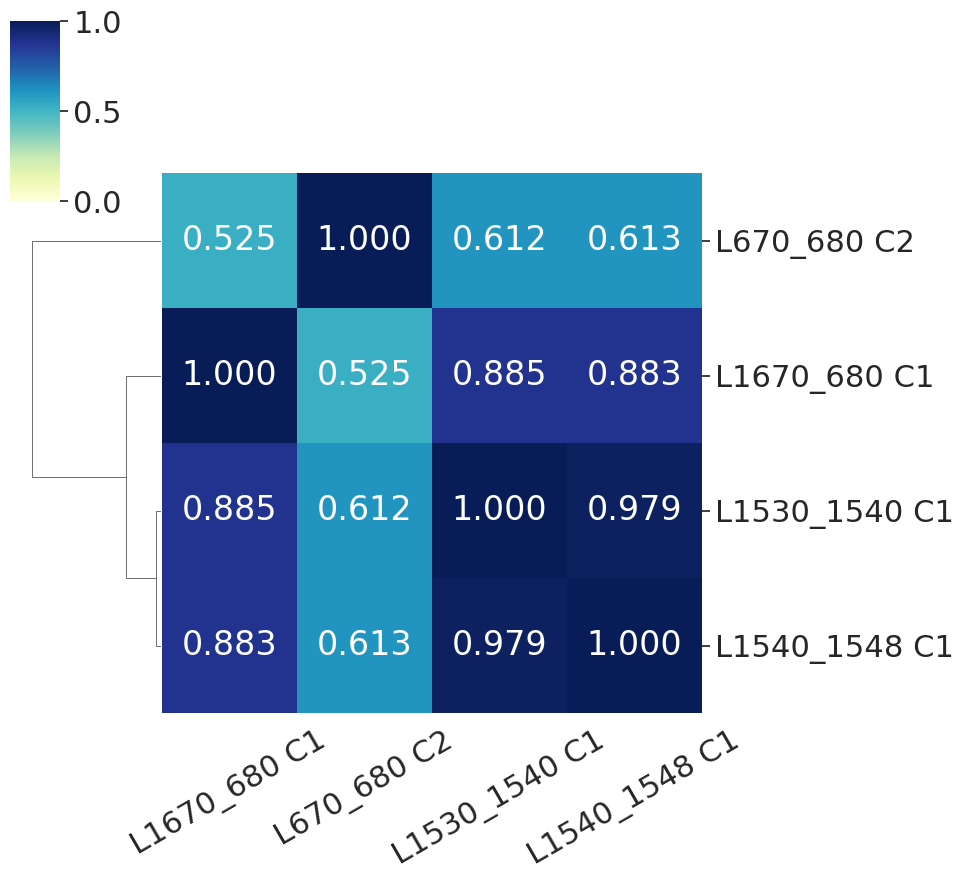

In [79]:
scorelist=[L670_score1[0:660],L670_score2[0:660],L1530_score1[0:660],L1540_score1[0:660]]
namelists=['L1670_680 C1','L670_680 C2','L1530_1540 C1','L1540_1548 C1']
n=4
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)

plt.figure(figsize=(4,4))
hm=sns.clustermap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f",vmin=0, vmax=1,col_cluster=False)
plt.setp(hm.ax_heatmap.get_xticklabels(), rotation=30) 
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/670VS1530.PCC.pdf")
#plt.close()

<Figure size 400x400 with 0 Axes>

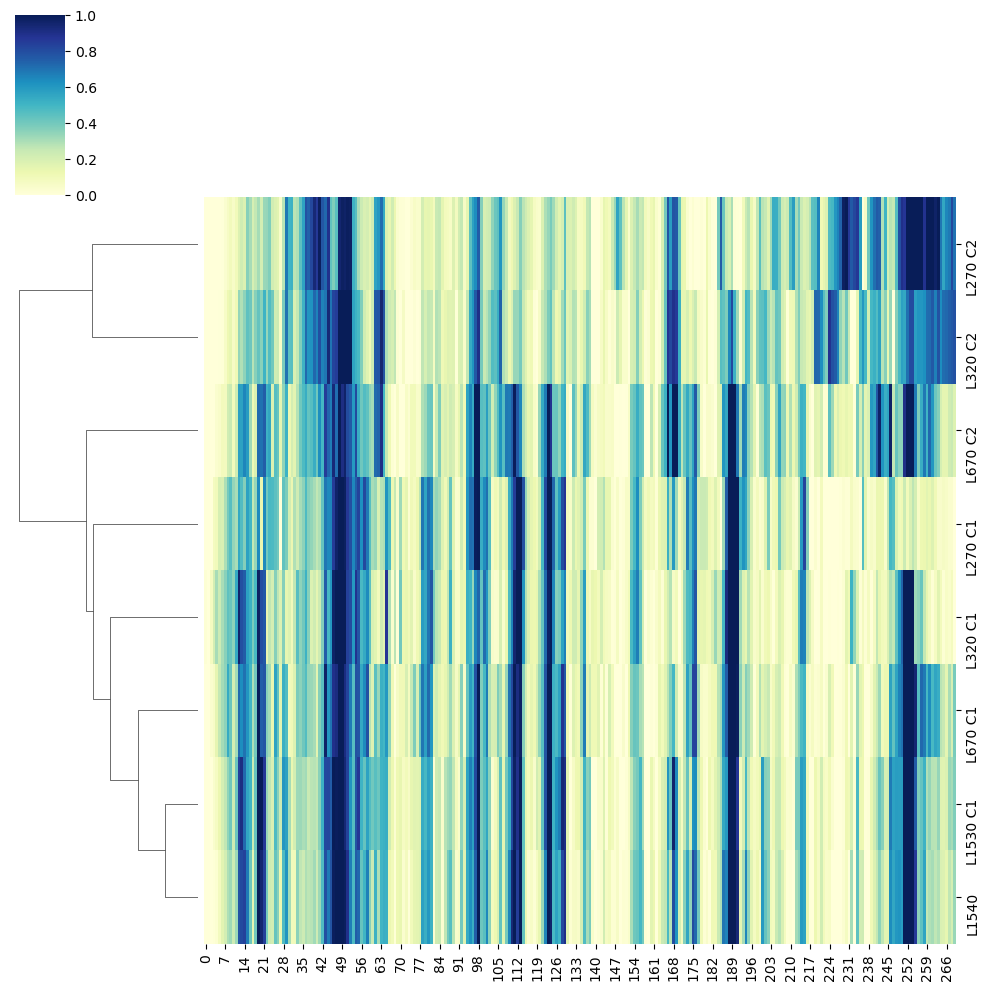

In [77]:
scorelist=[L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270],L670_score1[0:270],L670_score2[0:270],L1530_score1[0:270],L1540_score1[0:270]]
namelists=['L270 C1','L270 C2','L320 C1','L320 C2','L670 C1','L670 C2','L1530 C1','L1540']
n=8
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)
df=pd.DataFrame(scorelist, index=namelists)
plt.figure(figsize=(4,4))
sns.clustermap(df,col_cluster=False,cmap="YlGnBu")
plt.show()

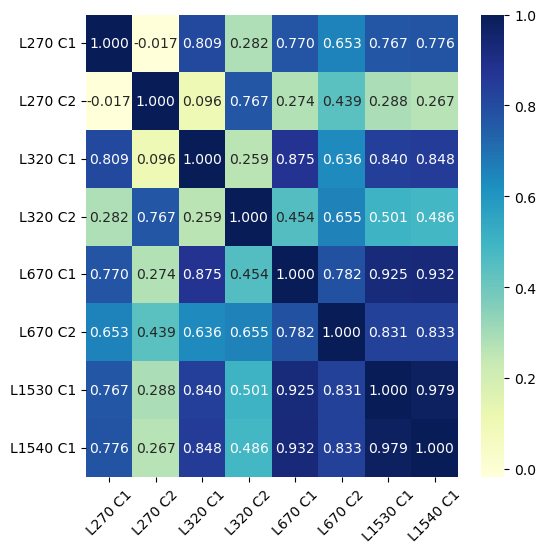

In [83]:
scorelist=[L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270],L670_score1[0:270],L670_score2[0:270],L1530_score1[0:270],L1540_score1[0:270]]
namelists=['L270 C1','L270 C2','L320 C1','L320 C2','L670 C1','L670 C2','L1530 C1','L1540 C1']
n=8
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)
df=pd.DataFrame(scorelist, index=namelists)
plt.figure(figsize=(6,6))
sns.heatmap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f")
#plt.title("Pearson Correlation coefficient of 16S")
plt.xticks(rotation=45)
plt.show()


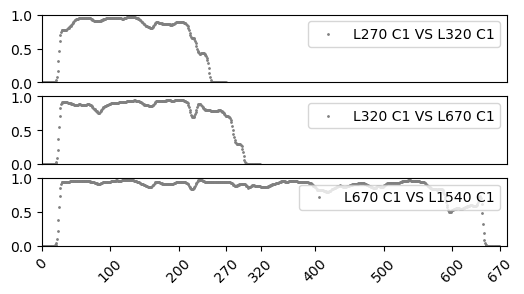

In [75]:
from scipy.ndimage import gaussian_filter1d
L270_320_correlation=SHAPEWindowcorrelation(L270_score1[0:270],L320_score1[0:270],50)
L270_320_correlation_smooth=gaussian_filter1d(L270_320_correlation, sigma=2)

L320_670_correlation=SHAPEWindowcorrelation(L320_score1[0:320],L670_score1[0:320],50)
L320_670_correlation_smooth=gaussian_filter1d(L320_670_correlation, sigma=2)

L670_full_correlation=SHAPEWindowcorrelation(L670_score1[0:670],L1540_score1[0:670],50)
L670_full_correlation_smooth=gaussian_filter1d(L670_full_correlation, sigma=2)

fig = plt.figure(figsize = (6,3))
ax = fig.add_subplot(3,1,1) 
plt.scatter([i for i in range(270)], L270_320_correlation_smooth.tolist(), s = 1,color ='gray' ,label='L270 C1 VS L320 C1')
plt.legend(loc="upper right")
plt.xticks([])
plt.xlim(0,680)
plt.ylim(0,1)

ax = fig.add_subplot(3,1,2) 
plt.scatter([i for i in range(320)], L320_670_correlation_smooth.tolist(), s = 1,color ='gray' ,label='L320 C1 VS L670 C1')
plt.legend(loc="upper right")
plt.xticks([])
plt.xlim(0,680)
plt.ylim(0,1)

ax = fig.add_subplot(3,1,3) 
plt.scatter([i for i in range(670)], L670_full_correlation_smooth.tolist(), s = 1,color ='gray' ,label='L670 C1 VS L1540 C1')
plt.legend(loc="upper right")
#plt.xticks([])
plt.xlim(0,680)
plt.ylim(0,1)
plt.xticks([0,100,200,270,320,400,500,600,670])
plt.xticks(rotation=45)
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/Transition PCC.pdf")
#plt.close()